In [60]:
"""
TRAFFIC DATA VISUALIZATION - JUPYTER NOTEBOOK CELLS
====================================================
Copy từng cell vào Jupyter Notebook của bạn
"""

# ============================================================================
# CELL 1: Import Libraries và Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


📂 LOAD DỮ LIỆU NPZ ĐÃ XỬ LÝ
📊 GRAPH STRUCTURE
Number of nodes: 498
Number of features per node: 46
Number of edges (directed): 3480
Average degree (directed): 6.99
Coordinate range: lat=[10.78440,10.80062], lon=[106.68481,106.71023]

Feature names (46):
   1. distance
   2. frc
   3. speed_limit
   4. harmonic_average_speed
   5. median_speed
   6. average_speed
   7. std_speed
   8. average_travel_time
   9. median_travel_time
  10. travel_time_std
  ... and 36 more


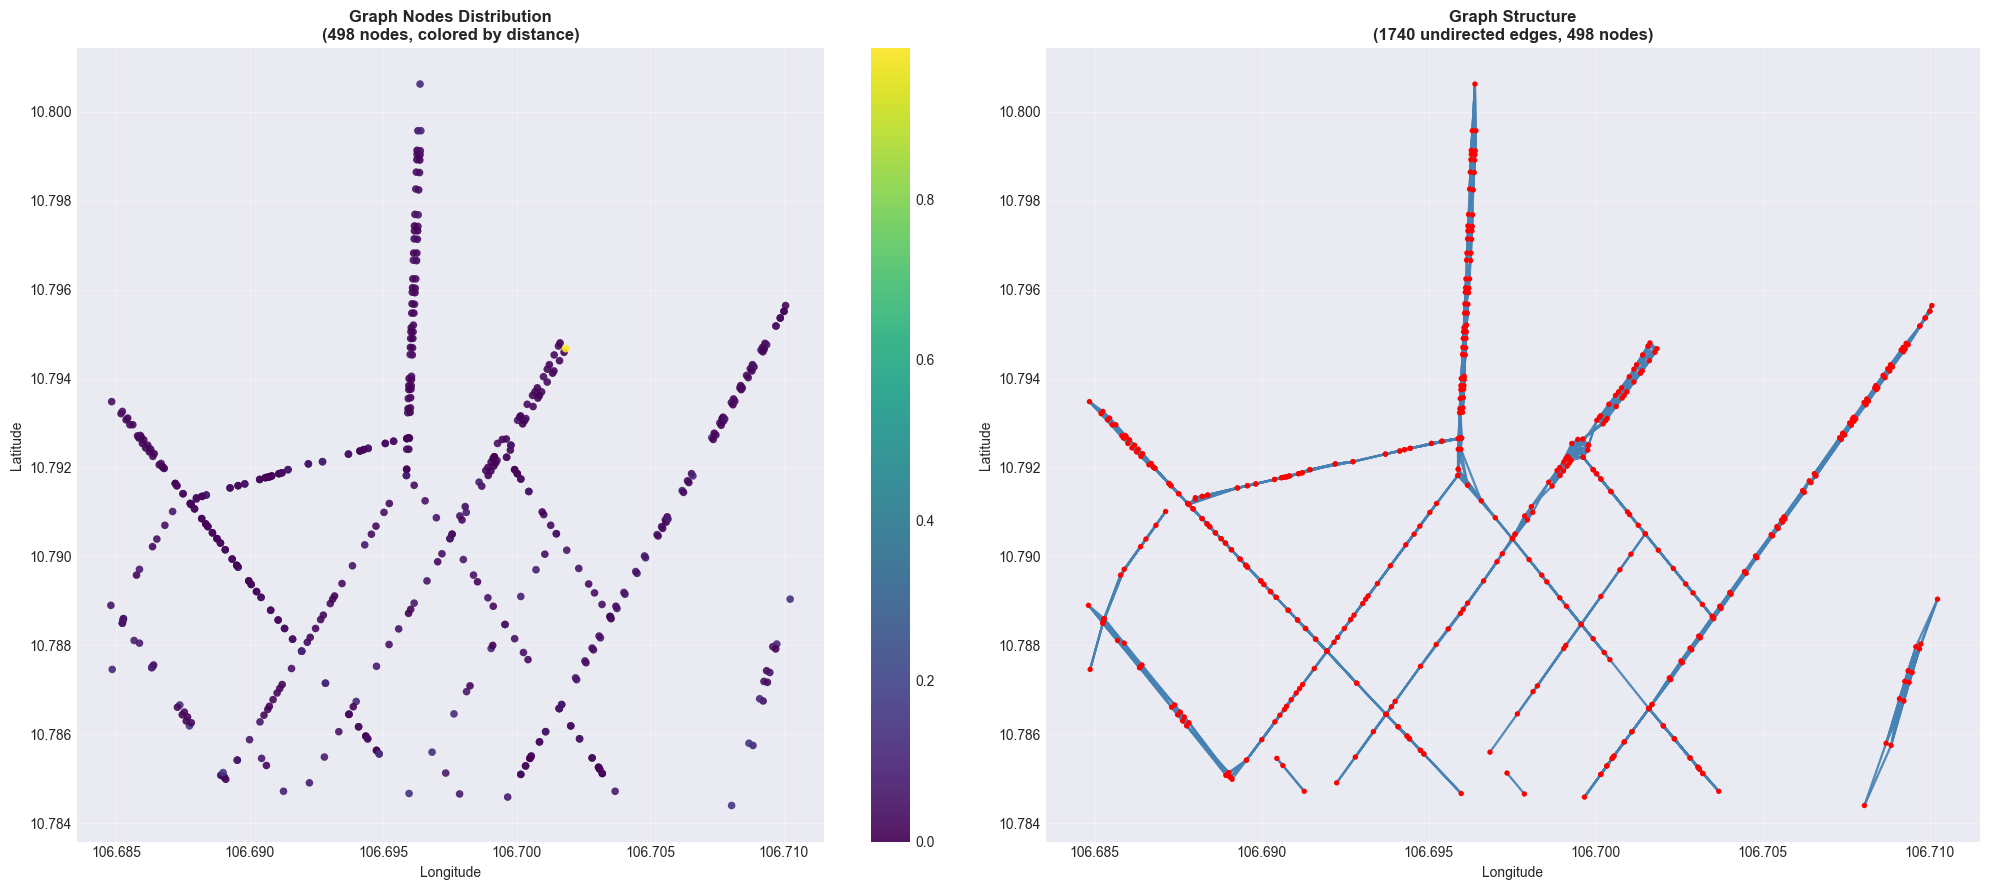

✓ Đã lưu: step7_graph_structure.png


In [ ]:
print("=" * 70)
print("📂 LOAD DỮ LIỆU NPZ ĐÃ XỬ LÝ")
print("=" * 70)

# Load Traffic Features NPZ
BASE_DIR = Path.cwd()  # notebooks/

# Load Graph Structure NPZ
graph_npz_file = (
    BASE_DIR
    / ".."
    / ".."
    / "data"
    / "processed"
    / "graph_structure"
    / "graph_structure_20260311_161339.npz"
).resolve()
graph_npz = np.load(graph_npz_file, allow_pickle=True)

# Trích xuất graph structure
node_features = graph_npz["node_features"]
edge_index = graph_npz["edge_index"]  # 0-based indices (DO NOT subtract 1)
coordinates = graph_npz["coordinates"]
feature_names = graph_npz["feature_names"]

print("=" * 70)
print("📊 GRAPH STRUCTURE")
print("=" * 70)
print(f"Number of nodes: {node_features.shape[0]}")
print(f"Number of features per node: {node_features.shape[1]}")
print(f"Number of edges (directed): {edge_index.shape[1]}")
print(f"Average degree (directed): {edge_index.shape[1] / node_features.shape[0]:.2f}")

print(
    "Coordinate range: "
    f"lat=[{coordinates[:, 0].min():.5f},{coordinates[:, 0].max():.5f}], "
    f"lon=[{coordinates[:, 1].min():.5f},{coordinates[:, 1].max():.5f}]"
)

print(f"\nFeature names ({len(feature_names)}):")
for i, name in enumerate(feature_names[:10]):
    print(f"  {i+1:2d}. {name}")
if len(feature_names) > 10:
    print(f"  ... and {len(feature_names) - 10} more")

# Visualize graph
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# ── Plot 1: Node distribution ─────────────────────────────────────────────
scatter = axes[0].scatter(
    coordinates[:, 1], coordinates[:, 0],
    c=node_features[:, 0], cmap='viridis',
    s=30, alpha=0.9, edgecolors='none'
)
axes[0].set_title(
    f'Graph Nodes Distribution\n({node_features.shape[0]} nodes, colored by {feature_names[0]})',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0])

# ── Plot 2: Edges VẼ TRƯỚC với màu rõ, nodes NHỎ lại ─────────────────────
# Vẽ edges — màu xanh đậm, đủ dày để thấy dù ngắn
for i in range(edge_index.shape[1]):
    s = int(edge_index[0, i])
    e = int(edge_index[1, i])
    axes[1].plot(
        [coordinates[s, 1], coordinates[e, 1]],
        [coordinates[s, 0], coordinates[e, 0]],
        color='steelblue', alpha=0.7, linewidth=1.5, solid_capstyle='round'
    )

# Nodes NHỎ (s=15) và không có edgecolor để không che edges
axes[1].scatter(
    coordinates[:, 1], coordinates[:, 0],
    c='red', s=15, alpha=1.0, zorder=5, edgecolors='none'
)

axes[1].set_title(
    f'Graph Structure\n'
    f'({edge_index.shape[1]//2} undirected edges, {node_features.shape[0]} nodes)',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Đã lưu: step7_graph_structure.png")

In [62]:
import folium
import numpy as np
from IPython.display import display

# tọa độ
lats = coordinates[:,0]
lons = coordinates[:,1]

center_lat = np.mean(lats)
center_lon = np.mean(lons)

# tạo map
m = folium.Map(location=[center_lat, center_lon], zoom_start=15)

# vẽ edges (edge_index là 0-based)
for i in range(edge_index.shape[1]):

    s = int(edge_index[0, i])
    e = int(edge_index[1, i])

    if 0 <= s < len(coordinates) and 0 <= e < len(coordinates):
        folium.PolyLine(
            [
                [coordinates[s, 0], coordinates[s, 1]],
                [coordinates[e, 0], coordinates[e, 1]],
            ],
            color="blue",
            weight=1,
            opacity=0.3,
        ).add_to(m)

# vẽ nodes
for i in range(len(coordinates)):
    folium.CircleMarker(
        location=[coordinates[i,0], coordinates[i,1]],
        radius=3,
        color="red",
        fill=True
    ).add_to(m)

m.save("test_map.html")